# 01 – Data Loading

This notebook demonstrates:
1. Loading TLE data from a local file
2. Propagating satellite orbits with SGP4 (via `skyfield`)
3. Inspecting the raw feature time-series

In [6]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_tle_file, propagate_satellite, STEP_MIN, HOURS

## 1.1 Load TLE file

In [7]:
TLE_FILE = '../data/starlink_tle.txt'
tle_list = load_tle_file(TLE_FILE)
print(f'Loaded {len(tle_list)} satellite(s)')
for name, l1, l2 in tle_list:
    print(f'  {name}')

Loaded 31 satellite(s)
  STARLINK-1008
  STARLINK-1009
  STARLINK-1010
  STARLINK-1011
  STARLINK-1012
  STARLINK-1013
  STARLINK-1014
  STARLINK-1015
  STARLINK-1016
  STARLINK-1017
  STARLINK-1018
  STARLINK-1019
  STARLINK-1020
  STARLINK-1021
  STARLINK-1022
  STARLINK-1023
  STARLINK-1024
  STARLINK-1025
  STARLINK-1026
  STARLINK-1027
  STARLINK-2021
  STARLINK-2022
  STARLINK-2023
  STARLINK-2024
  STARLINK-2025
  STARLINK-2026
  STARLINK-2027
  STARLINK-2028
  STARLINK-3029
  STARLINK-3030
  STARLINK-3031


## 1.2 SGP4 Propagation

Each TLE is propagated at $\Delta t = 5$ min intervals over a 48-hour window:
$$\mathbf{s}(t) = \text{SGP4}(\text{TLE},\; t)$$

In [8]:
name, l1, l2 = tle_list[0]
records = propagate_satellite(name, l1, l2, hours=HOURS, step_min=STEP_MIN)
print(f'Records generated: {len(records)}')
print('Sample record:', {k: v if k != "features" else v.shape for k, v in records[0].items()})

Records generated: 576
Sample record: {'features': (18,), 'x': 1678.7753671090247, 'y': 4032.872933798035, 'z': 5366.54706229306}


## 1.3 Inspect the position time-series

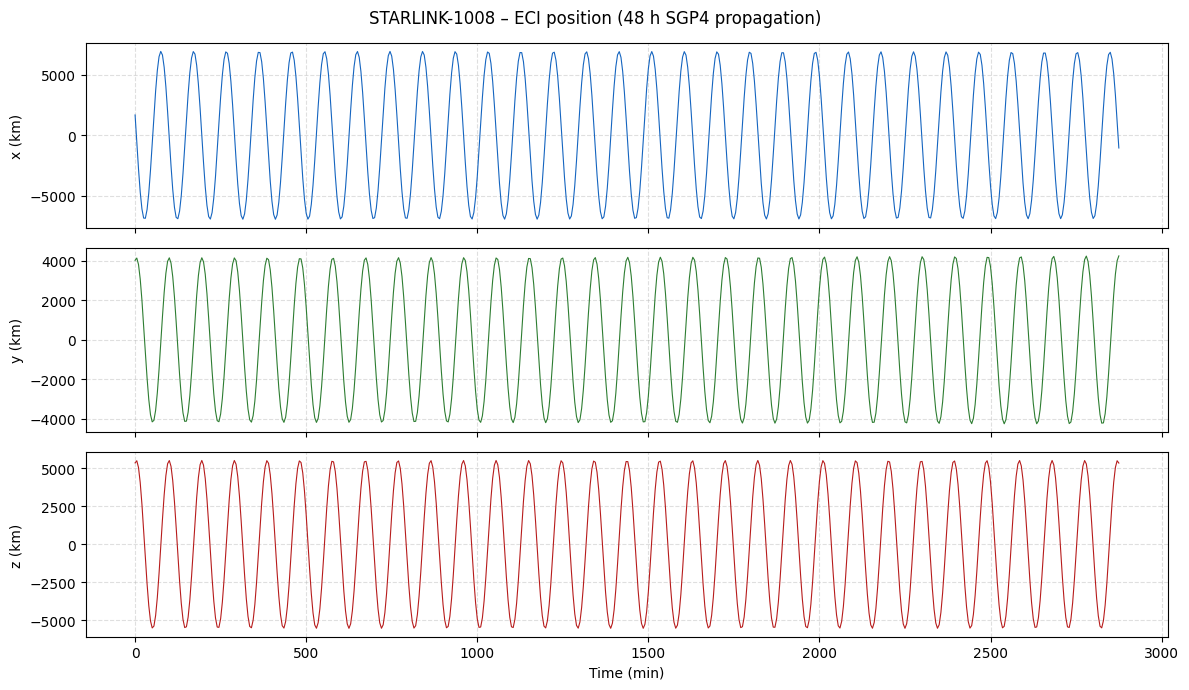

In [9]:
xs = [r['x'] for r in records]
ys = [r['y'] for r in records]
zs = [r['z'] for r in records]
t  = [i * STEP_MIN for i in range(len(records))]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, vals, lbl, col in zip(axes, [xs, ys, zs], ['x (km)', 'y (km)', 'z (km)'],
                               ['#1565C0', '#2E7D32', '#B71C1C']):
    ax.plot(t, vals, color=col, linewidth=0.8)
    ax.set_ylabel(lbl)
    ax.grid(linestyle='--', alpha=0.4)
axes[-1].set_xlabel('Time (min)')
fig.suptitle(f'{name} – ECI position (48 h SGP4 propagation)')
plt.tight_layout()
plt.show()

## 1.4 3-D orbit plot

In [ ]:
import plotly.graph_objects as go

fig3d = go.Figure(
    go.Scatter3d(x=xs, y=ys, z=zs, mode='lines',
                 line=dict(color='royalblue', width=2))
)
fig3d.update_layout(
    title=f'{name} – 48-h SGP4 orbit',
    scene=dict(xaxis_title='X (km)', yaxis_title='Y (km)', zaxis_title='Z (km)')
)
fig3d.show()